<a href="https://colab.research.google.com/github/wkdqkfwkd01/capston-practice-1/blob/main/%EC%BA%A1%EC%8A%A4%ED%86%A4%EB%94%94%EC%9E%90%EC%9D%B8_%EA%B5%AC%EB%93%9C%EC%94%A8%EC%97%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#캡스톤디자인 프로젝트

## 객체 탐지 모델(yoloV8n) 실행

In [ ]:
# 1. 내 구글 드라이브를 코랩과 연결
from google.colab import drive
drive.mount('/content/drive')

# 2. 딥러닝 모델을 돌리기 위한 YOLOv8 설치
!pip install ultralytics -q
import torch
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

print(" 환경 세팅 및 드라이브 마운트 완료!")

In [ ]:
# 공유한 merged_best.pt파일의 경로를 올려주세요.
model_path = '/content/drive/MyDrive/Capstone_Project/merged_best.pt'

try:
    model = YOLO(model_path)
    print(f" 모델 로드 성공: {model_path.split('/')[-1]}")
    print(" 이제 사진을 테스트할 준비가 끝났습니다!")
except Exception as e:
    print(f" 모델 로드 실패. 경로를 다시 확인해주세요.\n에러 내용: {e}")

 모델 로드 성공: merged_best.pt
 이제 사진을 테스트할 준비가 끝났습니다!


🔍 'test_food.jpg' 이미지를 분석 중입니다...

image 1/1 /content/drive/MyDrive/음식 테스트 사진2.jpg: 416x320 (no detections), 100.9ms
Speed: 1.7ms preprocess, 100.9ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 320)


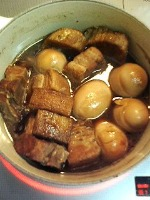

In [ ]:
# 1. 인터넷에서 구한 테스트용 음식 사진을 코랩(왼쪽 파일 탐색기)에 업로드하세요.
# 업로드한 사진의 이름을 아래에 적어줍니다.
test_image_name = 'test_food.jpg' # ★ 여기에 업로드한 사진 이름을 적으세요!
test_image_path = f'/content/drive/MyDrive/음식 테스트 사진2.jpg'

print(f"🔍 '{test_image_name}' 이미지를 분석 중입니다...")

# 2. 모델 예측 실행 (conf=0.4는 30% 이상 확신할 때만 표시하라는 뜻)
results = model.predict(source=test_image_path, conf=0.3)

# 3. 예측 결과를 이미지 위에 표시
res_image = results[0].plot()

# 4. 예측 결과 화면 출력
cv2_imshow(res_image)

In [ ]:

nutrition_db = {
    "jiaozi": {"cal": 250, "carbs": 30, "pro": 10, "fat": 10},
    "toast": {"cal": 200, "carbs": 35, "pro": 5, "fat": 4},
    "chicken": {"cal": 500, "carbs": 0, "pro": 30, "fat": 40}
}

detected_foods = [results[0].names[int(c)] for c in results[0].boxes.cls]
print(" AI가 인식한 음식:", detected_foods)

total_nutrition = {"cal": 0, "carbs": 0, "pro": 0, "fat": 0}

for food in detected_foods:
    if food in nutrition_db:
        total_nutrition["cal"] += nutrition_db[food]["cal"]
        total_nutrition["carbs"] += nutrition_db[food]["carbs"]
        total_nutrition["pro"] += nutrition_db[food]["pro"]
        total_nutrition["fat"] += nutrition_db[food]["fat"]
    else:
        print(f" '{food}'는 아직 영양소 DB에 없는 음식입니다.")

print("-" * 30)
print(" 총 섭취 칼로리:", total_nutrition["cal"], "kcal")
print(f" 탄수화물: {total_nutrition['carbs']}g")
print(f" 단백질: {total_nutrition['pro']}g")
print(f" 지방: {total_nutrition['fat']}g")
print("-" * 30)

NameError: name 'results' is not defined

# 현재 상태 정리
# 1. yolov8n.pt 기본모델로 백반사진 객체탐지 실행 성공
# 2. 기본 모델은 bowl, dining table만 잡고 음식 종류는 못 맞춤
# 3. 데이터셋으로 훈련 완료
# 4. 테스트 진행중...